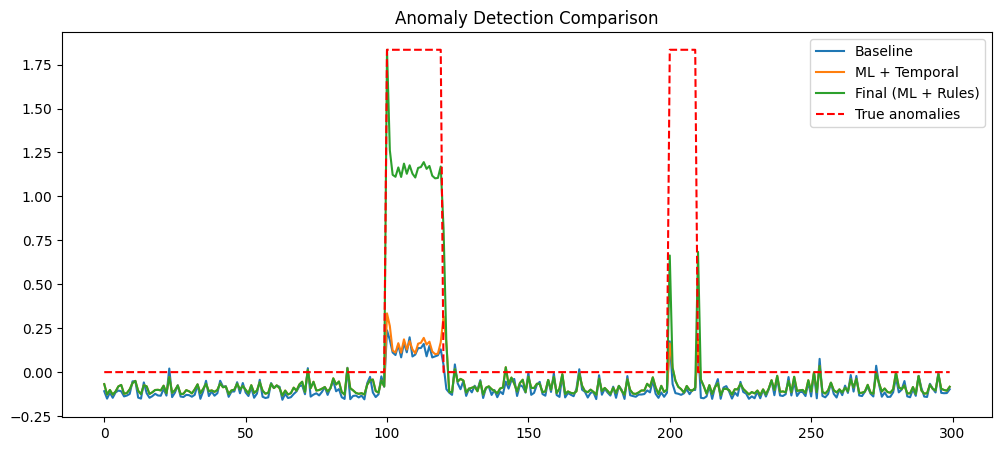

Normal example:


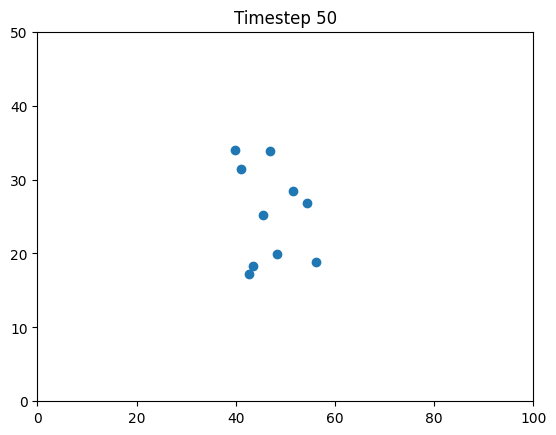

Anomaly example:


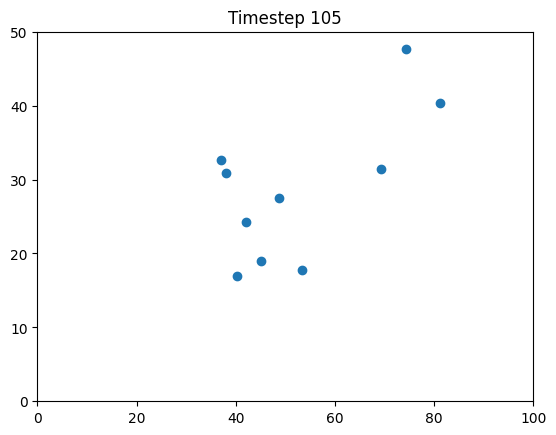

Baseline:
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       270
         1.0       0.70      0.70      0.70        30

    accuracy                           0.94       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.94      0.94      0.94       300

Improved (ML + Temporal):
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       270
         1.0       0.73      0.73      0.73        30

    accuracy                           0.95       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.95      0.95      0.95       300

Final (ML + Rules):
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       270
         1.0       0.73      0.73      0.73        30

    accuracy                           0.95       300
   macro avg       0.85      0.85      0.85       300
weighted avg      

In [ ]:
# =========================================
# 1. Imports
# =========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from scipy.spatial import ConvexHull

np.random.seed(42)

# =========================================
# 2. Parameters
# =========================================
T = 300
N_PLAYERS = 10
FIELD_X = 100
FIELD_Y = 50

# =========================================
# 3. Generate data
# =========================================
def generate_normal_data(T, N):
    center = np.array([50, 25])
    offsets = np.random.uniform(-10, 10, size=(N, 2))

    data = []

    for t in range(T):
        center = center + np.random.normal(0, 0.5, size=2)

        positions = []
        for i in range(N):
            noise = np.random.normal(0, 0.3, size=2)
            pos = center + offsets[i] + noise

            pos[0] = np.clip(pos[0], 0, FIELD_X)
            pos[1] = np.clip(pos[1], 0, FIELD_Y)

            positions.append(pos)

        data.append(np.array(positions))

    return np.array(data)

# =========================================
# 4. Inject anomalies
# =========================================
def inject_anomalies(data):
    data = data.copy()
    labels = np.zeros(len(data))

    # Structural anomaly (spread)
    for t in range(100, 120):
        data[t, :3] += np.array([30, 15])
        labels[t] = 1

    # Positional anomaly (global shift)
    for t in range(200, 210):
        data[t] += np.array([20, -10])
        labels[t] = 1

    return data, labels

# =========================================
# 5. Feature extraction (UPDATED)
# =========================================
def compute_features(data):
    features = []
    prev_center = None

    for t in range(len(data)):
        positions = data[t]
        center = np.mean(positions, axis=0)

        # center velocity
        if prev_center is None:
            center_velocity = 0
        else:
            center_velocity = np.linalg.norm(center - prev_center)

        prev_center = center

        # spread
        dists = np.linalg.norm(positions - center, axis=1)
        spread = np.mean(dists)

        # pairwise distance
        pairwise = []
        for i in range(len(positions)):
            for j in range(i+1, len(positions)):
                pairwise.append(np.linalg.norm(positions[i] - positions[j]))
        pairwise_mean = np.mean(pairwise)

        # convex hull area
        try:
            hull = ConvexHull(positions)
            area = hull.volume
        except:
            area = 0

        # aspect ratio
        cov = np.cov(positions.T)
        eigvals = np.linalg.eigvals(cov)
        aspect_ratio = max(eigvals) / (min(eigvals) + 1e-5)

        features.append([spread, pairwise_mean, area, aspect_ratio, center_velocity])

    return np.array(features)

# =========================================
# 6. Temporal features
# =========================================
def add_temporal_features(features):
    velocity = [0]
    acceleration = [0]

    for t in range(1, len(features)):
        v = np.linalg.norm(features[t] - features[t-1])
        velocity.append(v)

    for t in range(1, len(velocity)):
        a = abs(velocity[t] - velocity[t-1])
        acceleration.append(a)

    velocity = np.array(velocity)
    acceleration = np.array(acceleration)

    return np.column_stack([features, velocity, acceleration])

# =========================================
# 7. Rule-based reasoning (UPDATED)
# =========================================
def rule_based_score(features):
    scores = []

    for f in features:
        spread, pairwise, area, aspect, center_velocity = f

        score = 0

        # structural anomalies
        if spread > 15:
            score += 1
        if aspect > 5:
            score += 1
        if area > 800:
            score += 1

        # positional anomaly
        if center_velocity > 5:
            score += 1

        scores.append(score)

    return np.array(scores)

# =========================================
# 8. Generate dataset
# =========================================
data = generate_normal_data(T, N_PLAYERS)
data, true_labels = inject_anomalies(data)

features = compute_features(data)
features_full = add_temporal_features(features)

# =========================================
# 9. Scaling
# =========================================
scaler = StandardScaler()
X_base = scaler.fit_transform(features)
X_full = scaler.fit_transform(features_full)

# =========================================
# 10. Models
# =========================================
iso = IsolationForest(contamination=0.1, random_state=42)
baseline_scores = -iso.fit(X_base).decision_function(X_base)

iso2 = IsolationForest(contamination=0.1, random_state=42)
improved_scores = -iso2.fit(X_full).decision_function(X_full)

rule_scores = rule_based_score(features)

# hybrid
final_score = improved_scores + 0.5 * rule_scores

# =========================================
# 11. Visualization
# =========================================
plt.figure(figsize=(12,5))
plt.plot(baseline_scores, label="Baseline")
plt.plot(improved_scores, label="ML + Temporal")
plt.plot(final_score, label="Final (ML + Rules)")
plt.plot(true_labels * max(final_score), 'r--', label="True anomalies")
plt.legend()
plt.title("Anomaly Detection Comparison")
plt.show()

# =========================================
# 12. Example frames
# =========================================
def plot_frame(t):
    pos = data[t]
    plt.scatter(pos[:,0], pos[:,1])
    plt.xlim(0, FIELD_X)
    plt.ylim(0, FIELD_Y)
    plt.title(f"Timestep {t}")
    plt.show()

print("Normal example:")
plot_frame(50)

print("Anomaly example:")
plot_frame(105)

# =========================================
# 13. Evaluation
# =========================================
def to_binary(scores, percentile=90):
    threshold = np.percentile(scores, percentile)
    return (scores > threshold).astype(int)

baseline_pred = to_binary(baseline_scores)
improved_pred = to_binary(improved_scores)
final_pred = to_binary(final_score)

print("Baseline:")
print(classification_report(true_labels, baseline_pred))

print("Improved (ML + Temporal):")
print(classification_report(true_labels, improved_pred))

print("Final (ML + Rules):")
print(classification_report(true_labels, final_pred))